# Data Cleaning

## Objective

The objective of this phase is to prepare the datasets for analysis by validating data types, handling missing values, investigating duplicate records, and improving overall data quality.

## Data Cleaning Tasks

- Load all datasets
- Validate data types
- Convert date columns to datetime
- Handle missing values
- Investigate duplicate records
- Validate cleaned datasets

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Step 1: Validate Data Types

In this step, the data types of each dataset are validated to ensure that every column has the appropriate type before applying any cleaning operations.

In [2]:
import pandas as pd

from retailpulse.utils import (check_data_types , load_datasets )

In [3]:
(
    orders,
    customers,
    geolocation,
    items,
    payments,
    reviews,
    products,
    sellers,
    categories,
) = load_datasets()

In [4]:
check_data_types(orders, "Orders")
check_data_types(products, "Products")
check_data_types(customers, "Customers")
check_data_types(items, "Order Items")
check_data_types(payments, "Order Payments")
check_data_types(reviews, "Order Reviews")
check_data_types(sellers, "Sellers")
check_data_types(categories, "Product Category Name Translation")
check_data_types(geolocation, "Geolocation")

Dataset: Orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Dataset: Products
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
Dataset: Customers
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
Dataset: Order Items
order_id                   str
order_item_id            int64
product_id    

### Observations

- Most categorical columns are correctly stored as string (`str`).
- Numerical columns are stored using appropriate numeric data types (`int64` and `float64`).
- All date-related columns are still stored as strings and need to be converted to the `datetime` data type.
- No incorrect data types were identified in the remaining columns.

## Step 2: Convert Date Columns

Date and time columns are currently stored as strings (`str`). In this step, these columns will be converted to the `datetime` data type to enable time-based analysis such as extracting years, months, weekdays, and calculating delivery durations.

In [5]:
from retailpulse.utils import convert_to_datetime

In [6]:
orders_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = convert_to_datetime(orders, orders_date_columns)

In [7]:
items_date_columns = [
    "shipping_limit_date",
]

items = convert_to_datetime(items, items_date_columns)

In [8]:
reviews_date_columns = [
    "review_creation_date",
    "review_answer_timestamp",
]

reviews = convert_to_datetime(reviews, reviews_date_columns)

In [9]:
check_data_types(orders, "Orders")
check_data_types(items, "Order Items")
check_data_types(reviews, "Order Reviews")

Dataset: Orders
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object
Dataset: Order Items
order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object
Dataset: Order Reviews
review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_ans

## Step 3: Handle Missing Values

In this step, missing values are investigated to understand their causes before deciding whether they should be removed, replaced, or retained.

In [10]:
from retailpulse.utils import analyze_missing_values

In [11]:
analyze_missing_values(orders, "Orders")
analyze_missing_values(products, "Products")
analyze_missing_values(reviews, "Order Reviews")
analyze_missing_values(items, "Order Items")
analyze_missing_values(payments, "Order Payments")
analyze_missing_values(sellers, "Sellers")
analyze_missing_values(categories, "Product Category Name Translation")
analyze_missing_values(geolocation, "Geolocation")
analyze_missing_values(customers, "Customers")

Dataset: Orders
                               Missing Values  Percentage (%)
order_delivered_customer_date            2965            2.98
order_delivered_carrier_date             1783            1.79
order_approved_at                         160            0.16
Dataset: Products
                            Missing Values  Percentage (%)
product_category_name                  610            1.85
product_name_lenght                    610            1.85
product_description_lenght             610            1.85
product_photos_qty                     610            1.85
product_weight_g                         2            0.01
product_length_cm                        2            0.01
product_height_cm                        2            0.01
product_width_cm                         2            0.01
Dataset: Order Reviews
                        Missing Values  Percentage (%)
review_comment_title             87656           88.34
review_comment_message           58247           58.70

### Observations

- Most datasets contain no missing values and are ready for analysis.
- Missing values in the Orders dataset are likely related to the order lifecycle (e.g., canceled or undelivered orders) and require further investigation before any cleaning action.
- The Products dataset contains missing values mainly in product-related attributes, suggesting that a small number of products have incomplete information.
- The Reviews dataset contains a high percentage of missing values in the review title and review message columns. This is expected because customers are not required to leave textual feedback when submitting a rating.
- No cleaning actions were applied at this stage because the causes of missing values must be understood before deciding how to handle them.

## Decision 1: Orders Dataset

In [12]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders.loc[orders["order_delivered_customer_date"].isna(),"order_status"]

6           invoiced
44           shipped
103         invoiced
128       processing
154          shipped
            ...     
99283       canceled
99313     processing
99347       canceled
99348    unavailable
99415    unavailable
Name: order_status, Length: 2965, dtype: str

### Decision: Orders Dataset

- Most missing values in the delivery-related columns are expected and correspond to orders that were canceled, unavailable, shipped, or still in progress.
- Therefore, these missing values represent the business process rather than data quality issues.
- Only a very small number of delivered orders (8 records) have a missing delivery date, which may indicate data inconsistencies and will be investigated later.
- No missing values were removed or imputed at this stage.

In [14]:
products[products["product_category_name"].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [15]:
products[
    products["product_category_name"].isna()
].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [16]:
missing_products = products[
    products["product_category_name"].isna()
]

missing_products_orders = pd.merge(
    missing_products,
    items,
    on="product_id",
    how="inner"
)

missing_products_orders.shape

(1603, 15)

In [17]:
missing_products_orders["product_id"].nunique()

610

### Decision: Products Dataset

- All 610 products with missing descriptive information appear in the sales records.
- This was verified by merging the Products and Order Items datasets using `product_id`.
- Since these products were actually sold, removing them would result in losing valid business transactions.
- Therefore, these records will be retained, and the missing values will only be handled if needed for a specific analysis.

### Decision: Reviews Dataset

- The missing values in `review_comment_title` and `review_comment_message` are expected because customers are not required to leave written feedback.
- These missing values represent user behavior rather than data quality issues.
- Therefore, no imputation or deletion will be performed.
- The review score remains available for all records and can still be used for customer satisfaction analysis.

# Duplicate Values Analysis

In this section, we identify duplicate records across all datasets to determine whether they represent actual data quality issues or valid business records. Any duplicate records will be carefully investigated before deciding whether they should be removed.

In [18]:
from retailpulse.utils import check_duplicates

In [19]:
check_duplicates(orders, "Orders")
check_duplicates(products, "Products")
check_duplicates(customers, "Customers")
check_duplicates(items, "Order Items")
check_duplicates(payments, "Order Payments")
check_duplicates(reviews, "Order Reviews")
check_duplicates(sellers, "Sellers")
check_duplicates(categories, "Product Categories")
check_duplicates(geolocation, "Geolocation")

Dataset: Orders
Duplicate Rows: 0
Dataset: Products
Duplicate Rows: 0
Dataset: Customers
Duplicate Rows: 0
Dataset: Order Items
Duplicate Rows: 0
Dataset: Order Payments
Duplicate Rows: 0
Dataset: Order Reviews
Duplicate Rows: 0
Dataset: Sellers
Duplicate Rows: 0
Dataset: Product Categories
Duplicate Rows: 0
Dataset: Geolocation
Duplicate Rows: 261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP


In [20]:
geolocation.drop_duplicates().shape

(738332, 5)

In [21]:
geolocation.shape

(1000163, 5)

In [22]:
geolocation = geolocation.drop_duplicates()

In [23]:
check_duplicates(geolocation, "Geolocation")

Dataset: Geolocation
Duplicate Rows: 0


In [24]:
print(geolocation.shape)

(738332, 5)


### Observation

- The Geolocation dataset contained 261,831 fully duplicated rows.
- Inspection confirmed that these rows were identical across all columns.
- Since they did not provide any additional information, duplicate records were removed using `drop_duplicates()`.
- After cleaning, no duplicate rows remain in the dataset.

# Outlier Detection

In this section, numerical features are analyzed to identify potential outliers. Outliers will be investigated to determine whether they represent data entry errors or valid business observations before deciding on any treatment.

In [25]:
items.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


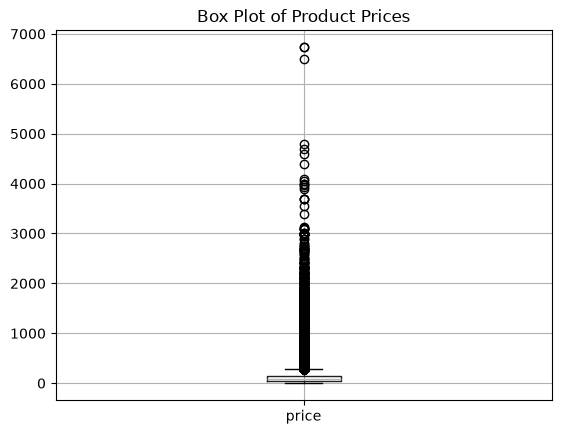

In [26]:
import matplotlib.pyplot as plt

items.boxplot(column="price")

plt.title("Box Plot of Product Prices")
plt.show()

In [27]:
Q1 = items["price"].quantile(0.25)
Q3 = items["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Q1: 39.9
Q3: 134.9
IQR: 95.0
Lower Bound: -102.6
Upper Bound: 277.4


In [28]:
price_outliers = items[items["price"] > upper_bound]

print(f"Number of outliers: {len(price_outliers)}")
print(f"Percentage: {len(price_outliers) / len(items) * 100:.2f}%")

Number of outliers: 8427
Percentage: 7.48%


In [29]:
items.nlargest(10, "price")[["order_id", "product_id", "price", "freight_value"]]

,order_id,product_id,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90,17.01


In [30]:
from retailpulse.utils import analyze_outliers


----- PRICE -----
Q1: 39.90
Q3: 134.90
IQR: 95.00
Lower Bound: -102.60
Upper Bound: 277.40
Number of Outliers: 8427
Percentage: 7.48%


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01


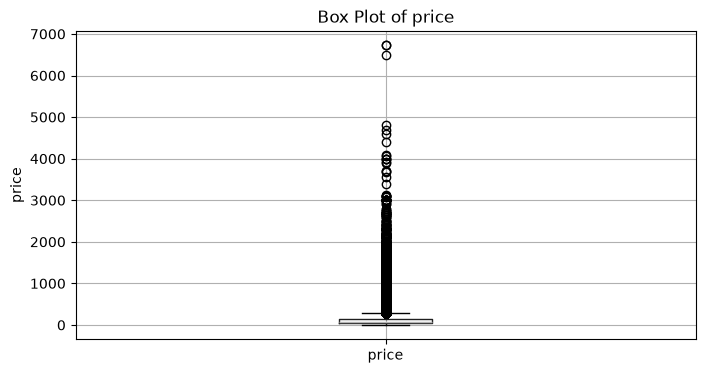


----- FREIGHT_VALUE -----
Q1: 13.08
Q3: 21.15
IQR: 8.07
Lower Bound: 0.98
Upper Bound: 33.25
Number of Outliers: 12134
Percentage: 10.77%


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-07-31 10:45:11,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40


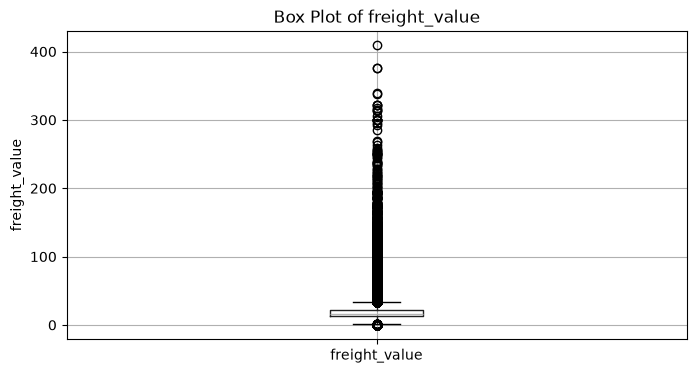

In [31]:
analyze_outliers(items, "price")

analyze_outliers(items, "freight_value")

### Observation

- The IQR method identified 12,134 potential outliers (10.77%) in the `freight_value` column.
- The highest freight costs ranged from approximately 300 to 410, which are reasonable for large, heavy, or long-distance deliveries.
- These values do not indicate invalid or erroneous records.
- Therefore, the detected outliers were retained because they represent valid business scenarios in an e-commerce environment.


----- PRODUCT_WEIGHT_G -----
Q1: 300.00
Q3: 1900.00
IQR: 1600.00
Lower Bound: -2100.00
Upper Bound: 4300.00
Number of Outliers: 4551
Percentage: 13.81%


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0
344,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,48.0,489.0,2.0,30000.0,50.0,50.0,30.0
509,53f92b0474f91fcb5bd188c6a8075c38,utilidades_domesticas,54.0,2952.0,3.0,30000.0,76.0,51.0,51.0
955,ceeba7d5636e59173cc5f484e913db3d,NaN,NaN,NaN,NaN,30000.0,65.0,65.0,65.0
1159,f97ad9066c718a6cef93dfcf253d3e0d,moveis_decoracao,63.0,886.0,5.0,30000.0,61.0,70.0,65.0
1469,363a9f5b97bf194da23858be722a7aa5,construcao_ferramentas_construcao,44.0,1455.0,6.0,30000.0,100.0,50.0,50.0
1514,dcfeedf441c38e5e7e58ffce194af2bb,beleza_saude,50.0,193.0,1.0,30000.0,67.0,64.0,61.0
1701,1c57458e824ca3d974ec1831a1a55e72,pet_shop,57.0,794.0,3.0,30000.0,79.0,2.0,63.0
1714,c04e948c6900ce99ac47d89b3b6d70cd,cool_stuff,33.0,1401.0,2.0,30000.0,70.0,37.0,70.0
1738,0a859d8dc68f6a746b4709217110c439,esporte_lazer,50.0,2871.0,1.0,30000.0,90.0,50.0,50.0


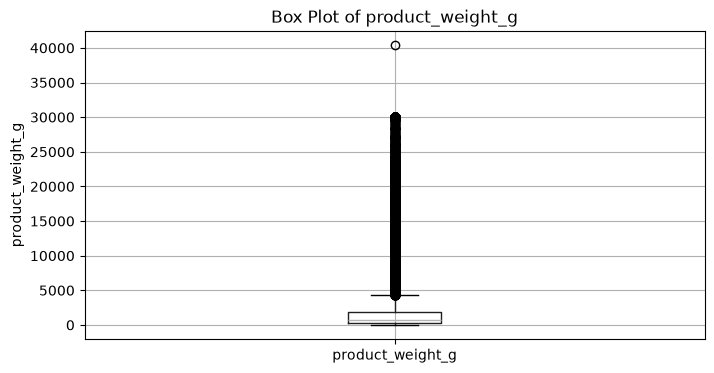


----- PRODUCT_LENGTH_CM -----
Q1: 18.00
Q3: 38.00
IQR: 20.00
Lower Bound: -12.00
Upper Bound: 68.00
Number of Outliers: 1380
Percentage: 4.19%


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
88,7f34b85142d1ef9e077a0da9ada27385,moveis_decoracao,59.0,1750.0,3.0,2300.0,105.0,3.0,70.0
357,f2a1b32f85cad59ff2a8444154ac25f0,climatizacao,51.0,2959.0,4.0,7800.0,105.0,10.0,40.0
788,11970aff9a8cf29a520127d0d8100901,moveis_decoracao,53.0,1750.0,3.0,2550.0,105.0,3.0,70.0
1019,d19284bf0893e07e80c26fe4ad33458e,moveis_decoracao,47.0,1750.0,4.0,2550.0,105.0,3.0,70.0
1151,3c07c4a8d970b0ffad8a97bd6b5e478c,moveis_decoracao,56.0,1750.0,3.0,2450.0,105.0,3.0,70.0
1403,184e91de5d4a87f023bba45c3e258349,moveis_decoracao,59.0,1941.0,4.0,2750.0,105.0,3.0,70.0
1614,43506d2b6b5e0535079f88c7dc51c4de,artes_e_artesanato,54.0,746.0,5.0,6850.0,105.0,5.0,65.0
2004,34742604f6cd1e891726b849b6890f81,esporte_lazer,47.0,1582.0,1.0,12000.0,105.0,46.0,46.0
2395,8c34ab7fffe8c063bc8c6da88aa92185,esporte_lazer,40.0,1034.0,3.0,200.0,105.0,10.0,15.0
2413,b4b48db403b9792d92330c4a79262763,moveis_decoracao,52.0,1492.0,3.0,2600.0,105.0,3.0,70.0


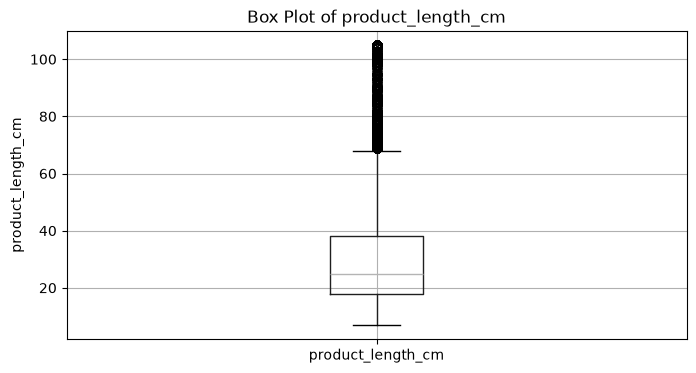


----- PRODUCT_HEIGHT_CM -----
Q1: 8.00
Q3: 21.00
IQR: 13.00
Lower Bound: -11.50
Upper Bound: 40.50
Number of Outliers: 1892
Percentage: 5.74%


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1498,e4e9fa024c5f014419b395452a41987c,esporte_lazer,59.0,355.0,1.0,3450.0,16.0,105.0,55.0
2026,8250ed49c0929b233a405e3ece4ce328,casa_construcao,22.0,579.0,2.0,30000.0,30.0,105.0,15.0
5209,426c58d69aa402e5397c4b6471420fbe,construcao_ferramentas_construcao,54.0,2312.0,1.0,3550.0,16.0,105.0,11.0
6007,d5365b4fc46af0e0679ce35e818b4b0a,esporte_lazer,59.0,355.0,2.0,15450.0,16.0,105.0,55.0
6105,83f6e0a993efdfa2bf9550a204422cb7,moveis_cozinha_area_de_servico_jantar_e_jardim,55.0,875.0,5.0,15800.0,60.0,105.0,15.0
6149,58306668d7263e8ebd2d5c69ef31cc23,beleza_saude,55.0,261.0,1.0,5300.0,25.0,105.0,12.0
6946,d14495a85be157b5cacef4eaaf825791,moveis_cozinha_area_de_servico_jantar_e_jardim,57.0,252.0,1.0,30000.0,31.0,105.0,31.0
9940,e42ad1ff7ad0843110435858ec10a2c6,esporte_lazer,49.0,1236.0,2.0,28450.0,65.0,105.0,25.0
10457,ef4f89f8ee26b84496a7f8e7dc76029d,casa_construcao,36.0,971.0,2.0,9150.0,50.0,105.0,15.0
12271,49e25af5dc73ad7ac3fefae03aea3e61,esporte_lazer,59.0,186.0,1.0,1000.0,17.0,105.0,17.0


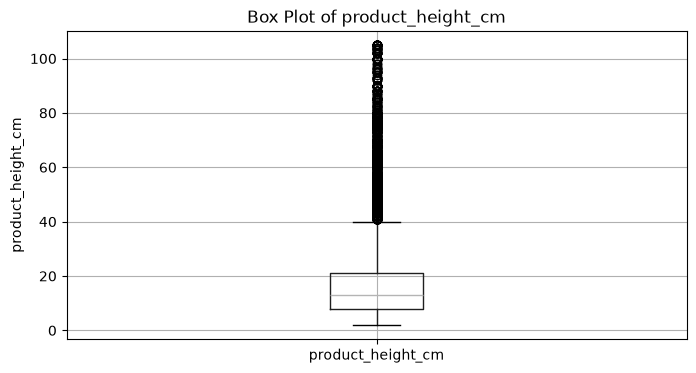


----- PRODUCT_WIDTH_CM -----
Q1: 15.00
Q3: 30.00
IQR: 15.00
Lower Bound: -7.50
Upper Bound: 52.50
Number of Outliers: 912
Percentage: 2.77%


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
26970,b17808303e15dd50538c011b44295427,cama_mesa_banho,56.0,502.0,3.0,1050.0,23.0,93.0,118.0
475,a2f4e28e50f60566eeb99f842ffc0fd9,instrumentos_musicais,57.0,374.0,1.0,5850.0,40.0,9.0,105.0
19326,6d30e5e702df2b8719d9c6be1bdf425b,cool_stuff,44.0,909.0,4.0,25000.0,27.0,23.0,105.0
23725,cb428376d66b5e216d2ef9f3b27fc172,instrumentos_musicais,59.0,209.0,2.0,5000.0,45.0,14.0,105.0
25181,3b17f6528c9e2a01b2f75f844a60ddae,instrumentos_musicais,59.0,326.0,1.0,5000.0,40.0,9.0,105.0
28739,3758055ab2434bd36ac78e00b15b5cf6,beleza_saude,52.0,1193.0,3.0,600.0,50.0,8.0,105.0
31050,83d68ad4e5707409089afff26a40b2df,brinquedos,33.0,112.0,1.0,13150.0,50.0,14.0,104.0
15308,e7248872169a7ab67e20c182aaf17976,instrumentos_musicais,60.0,327.0,1.0,5000.0,35.0,9.0,103.0
10256,68e6e8fd8c5f5b252b105d00daa9b57b,moveis_escritorio,51.0,758.0,1.0,13800.0,39.0,13.0,102.0
31163,e54c0428a8cf1b79f63823b92e20aacc,moveis_cozinha_area_de_servico_jantar_e_jardim,42.0,440.0,1.0,25800.0,39.0,13.0,102.0


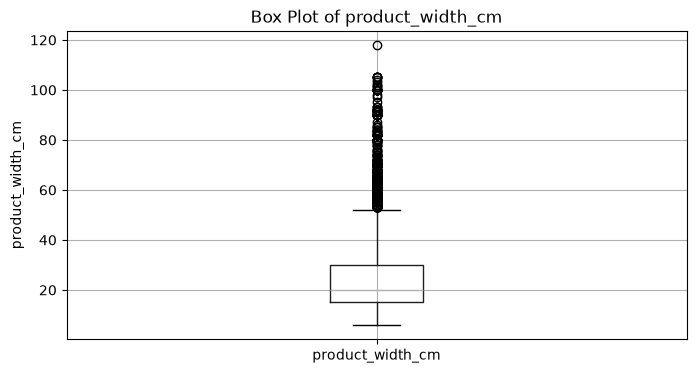

In [32]:
analyze_outliers(products, "product_weight_g")

analyze_outliers(products, "product_length_cm")

analyze_outliers(products, "product_height_cm")

analyze_outliers(products, "product_width_cm")

### Observation

The IQR method detected potential outliers in product weight and dimensions (`product_weight_g`, `product_length_cm`, `product_height_cm`, and `product_width_cm`).

After reviewing the largest values, the detected outliers were found to represent large or heavy products rather than data entry errors. Since these values are realistic for an e-commerce marketplace, they were retained for further analysis.


----- PAYMENT_VALUE -----
Q1: 56.79
Q3: 171.84
IQR: 115.05
Lower Bound: -115.78
Upper Bound: 344.41
Number of Outliers: 7981
Percentage: 7.68%


,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54
43232,a96610ab360d42a2e5335a3998b4718a,1,credit_card,10,4950.34
70320,b4c4b76c642808cbe472a32b86cddc95,1,credit_card,5,4809.44
6440,199af31afc78c699f0dbf71fb178d4d4,1,credit_card,8,4764.34
67546,8dbc85d1447242f3b127dda390d56e19,1,credit_card,8,4681.78


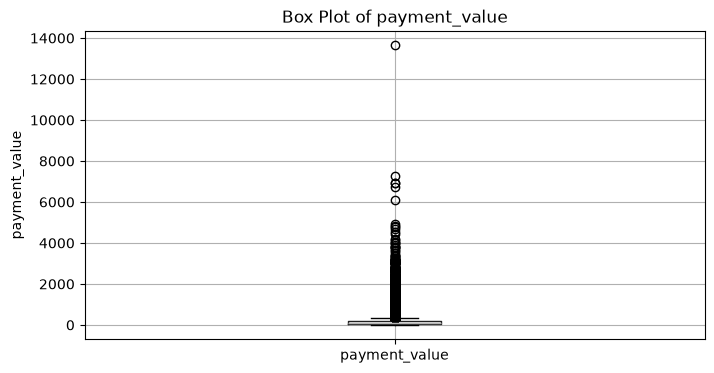


----- PAYMENT_INSTALLMENTS -----
Q1: 1.00
Q3: 4.00
IQR: 3.00
Lower Bound: -3.50
Upper Bound: 8.50
Number of Outliers: 6313
Percentage: 6.08%


,order_id,payment_sequential,payment_type,payment_installments,payment_value
2970,70b7e94ea46d3e8b5bc12a50186edaf0,1,credit_card,24,274.84
10791,859f516f2fc3f95772e63c5757ab0d5b,1,credit_card,24,609.56
12307,ff36cbc44b8f228e0449c92ef089c843,1,credit_card,24,756.49
18512,2b7dbe9be72b8f9733844c31055c0825,1,credit_card,24,345.39
21713,6ae2e8b8fac02522481d2a2f4ca4412c,1,credit_card,24,433.43
23024,90f864fe19d11549fa01eb81c4dd87e3,1,credit_card,24,588.58
36088,84d2098c97827c6327ed4d7be95e1fc8,1,credit_card,24,286.78
50401,ffb18bf111fa70edf316eb0390427986,1,credit_card,24,617.24
52846,63dbe0c8e63e5f1b4deec09d4f044a7f,1,credit_card,24,771.69
55094,fcbb6af360b31b05460c2c8e524588c0,1,credit_card,24,1194.38


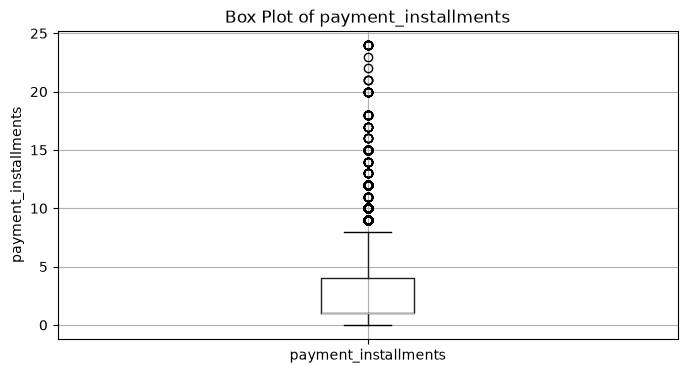

In [33]:
analyze_outliers(payments, "payment_value")

analyze_outliers(payments, "payment_installments")

### Observation

Potential outliers were detected in both `payment_value` and `payment_installments` using the IQR method.

After reviewing the largest values, the detected outliers were found to represent high-value purchases and extended installment plans rather than invalid or erroneous records. Therefore, all outliers were retained because they reflect legitimate customer transactions.

## Data Consistency Validation

In this section, the relationships between the project datasets are validated to ensure referential integrity. The objective is to verify that all foreign key values in child tables exist in their corresponding parent tables before proceeding to exploratory data analysis (EDA).

The validation includes the following relationships:

- Order Items → Products
- Order Items → Sellers
- Orders → Customers
- Payments → Orders
- Reviews → Orders

In [34]:
from retailpulse.utils import validate_foreign_keys

In [35]:
validate_foreign_keys(
    items,
    "product_id",
    products,
    "product_id"
)

 All 'product_id' values exist in 'product_id'.


In [36]:
validate_foreign_keys(
    items,
    "seller_id",
    sellers,
    "seller_id"
)

 All 'seller_id' values exist in 'seller_id'.


In [37]:
validate_foreign_keys(
    orders,
    "customer_id",
    customers,
    "customer_id"
)

 All 'customer_id' values exist in 'customer_id'.


In [38]:
validate_foreign_keys(
    payments,
    "order_id",
    orders,
    "order_id"
)

 All 'order_id' values exist in 'order_id'.


In [39]:
validate_foreign_keys(
    reviews,
    "order_id",
    orders,
    "order_id"
)

 All 'order_id' values exist in 'order_id'.


## Final Summary

The data cleaning process was successfully completed by performing the following tasks:

- Converted date columns to the appropriate datetime format.
- Investigated and handled missing values based on business understanding.
- Removed duplicate records from the geolocation dataset.
- Analyzed potential outliers using the IQR method and retained valid business observations.
- Validated referential integrity across all related datasets to ensure data consistency.

The datasets are now clean, consistent, and ready for Exploratory Data Analysis (EDA).

## Save Cleaned Datasets

After completing the data cleaning process, the cleaned datasets are saved separately to preserve the original raw data.

These processed datasets will be used in all subsequent stages of the project, including Exploratory Data Analysis (EDA), dashboard development, and predictive modeling.

In [42]:
from pathlib import Path

processed_path = Path("../data/processed")

# Save cleaned datasets
customers.to_csv(processed_path / "customers.csv", index=False)
geolocation.to_csv(processed_path / "geolocation.csv", index=False)
items.to_csv(processed_path / "items.csv", index=False)
payments.to_csv(processed_path / "payments.csv", index=False)
reviews.to_csv(processed_path / "reviews.csv", index=False)
orders.to_csv(processed_path / "orders.csv", index=False)
products.to_csv(processed_path / "products.csv", index=False)
sellers.to_csv(processed_path / "sellers.csv", index=False)
categories.to_csv(processed_path / "translation.csv", index=False)

print("✅ All cleaned datasets have been saved successfully.")

✅ All cleaned datasets have been saved successfully.
